In [2]:
# https://chatgpt.com/share/69e12940-0570-83e8-842f-0dde48ab5eac


In [3]:
import sklearn
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [4]:
# 1
# Load MNIST and inspect the data
# Recreate fetch_openml(..., as_frame=False), inspect X, y, print shapes, and plot one digit by reshaping it to 28×28. The point is to connect the flat 784-feature vector to the image.

dataset = fetch_openml(name="mnist_784", version=1, as_frame=False)
X, y = dataset["data"], dataset["target"]

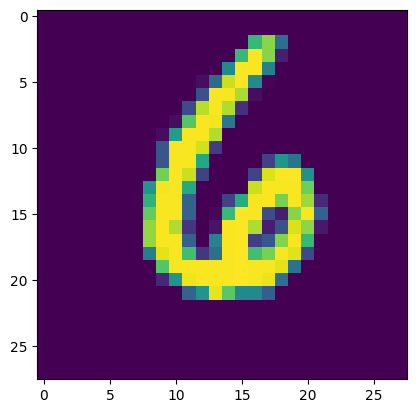

In [5]:
plt.imshow(X[431].reshape(28,28)) #heatmap in matplotlib, why matplot lib, as I would have to hand how to make box at what distance and which row etc then color based on the value

In [6]:
# 2
# Make the train/test split exactly as the chapter does
# Split the first 60,000 samples for training and the last 10,000 for testing. Check that the training set is already shuffled and understand why that matters for cross-validation stability
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(X_test[0])
print(y_test[0])

# cross validation don't do the randomization so we need to other wise if first 10000 are 1 and 2 only than the test might not contain these file

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0  96 121 121 121 121 190 121 190 190 162 218 121
 121 108   0   0   0   0   0   0   0   0   0   0   0  46 107 219 249 252
 252 252 252 252 253 252 252 252 252 252 252 251 240 240   0   0   0   0
   0   0   0   0  45 231 252 252 252 232 158 218 252 202 253 252 217 237
 252 252 252 192 151  26   0   0   0   0   0   0   0   0 233 252 252 252
 195  31   0  25  39  19  39  39  25 101 252 252 10

In [7]:
# 3
# Build a binary “5 detector”
# Create boolean targets like y_train_5 and y_test_5, then train SGDClassifier(random_state=42) and predict a single sample. This is the chapter’s first classifier example.
y_test_5 = y_test == '5'
y_train_5 = y_train =='5'

print(y_test_5)

from sklearn.linear_model import SGDClassifier

model = SGDClassifier(random_state=42)
model.fit(X_train, y_train_5)

from sklearn.metrics import accuracy_score
predictions = model.predict(X_test)

accuracy_score(predictions, y_test_5)

[False False False ...  True False False]


0.9644285714285714

In [8]:
# 4
# Measure accuracy with cross-validation, then break your own confidence with a dummy baseline
# Run cross_val_score() on the SGD model, then compare it to a DummyClassifier. The lesson is that accuracy can look excellent even when the classifier is basically useless on imbalanced data.

from sklearn.model_selection import cross_val_score


display(cross_val_score(SGDClassifier(random_state=42), X_train, y_train_5))


array([0.96428571, 0.95539683, 0.97071429, 0.96690476, 0.94380952])

from sklearn import DummyClassifier


In [9]:

cross_val_score(DummyClassifier(random_state=42), X_train, y_train_5)


array([0.9102381, 0.9102381, 0.9102381, 0.9102381, 0.9102381])

In [10]:
# 5
# Implement cross-validation manually with StratifiedKFold and clone
# Rebuild the 3-fold process yourself. This is worth doing once because it makes the mechanics of model evaluation concrete
# TODO


In [11]:
# 6
# Generate predictions with cross_val_predict() and build a confusion matrix
# Use cross_val_predict() for clean out-of-fold predictions, then compute confusion_matrix(). Interpret true negatives, false positives, false negatives, and true positives from the matrix entries.

# confusion matrix
#   p   n
#p  TP  FP
#n  FN  TN

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
y_train_pred_5 = cross_val_predict(SGDClassifier(random_state=42, n_jobs=-1), X_train, y_train_5, cv=3)
conf_matrix_val = confusion_matrix(y_train_5, y_train_pred_5)



In [12]:
# 7

# Core problem:
# The core problem: accuracy isn't enough
# Imagine a medical test for a rare disease. If only 1% of people have it, a model that always says "healthy" gets 99% accuracy — and is completely useless. This is why we need precision, recall, and F1.


# Compute precision, recall, and F1

# Lock the intuition with one-line questions
# Recall → “Out of all actual positives, how many did I catch?”
# Precision → “Out of all predicted positives, how many were correct?”
# recall literally means ***How many relevant items did the system successfully “recall” (retrieve)?*** came from google like early applications of ML/AI
# high precision and high recall is what we want

# Reproduce precision_score(), recall_score(), and f1_score(). Memorize the trade-off: precision answers “when it predicts positive, how often is it right?” and recall answers “how many real positives did it catch?”

# Logistic regression outputs probabilities, and we choose a threshold to classify outcomes. The threshold should be selected based on the problem context. If detecting all positives is critical (e.g., breast cancer screening), we prioritize recall and may lower the threshold, accepting lower precision

from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

precision = precision_score(y_train_5, y_train_pred_5)
recall = recall_score(y_train_5, y_train_pred_5)
f1 = f1_score(y_train_5, y_train_pred_5)

display(precision, recall, f1)

0.8150299509892902

0.7939876215738285

0.8043711931207452

In [13]:
sgd = SGDClassifier(random_state=42, n_jobs=-1)

y_scores = cross_val_predict(sgd, X_train, y_train_5, cv=3, method="decision_function")
# y_scores.shape → (60000,)  ← already 1D, no slicing needed

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [14]:
display(precisions, recalls, thresholds)

array([0.0897619 , 0.08976333, 0.08976475, ..., 1.        , 1.        ,
       1.        ], shape=(63001,))

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       3.53669319e-04, 1.76834660e-04, 0.00000000e+00], shape=(63001,))

array([-103996.10504197, -103870.59166012, -103559.3166037 , ...,
         27973.32127163,   29401.46811377,   32091.72847455],
      shape=(63000,))

In [15]:
# Move the decision threshold manually
# Use decision_function() to get scores, then test different thresholds. This is the fastest way to internalize how higher thresholds usually increase precision and reduce recall

# Score = “how far from boundary”
# Probability = “confidence after squashing into 0–1”

In [16]:
# plot the precision-recall curve and find a target threshold
# Recreate precision_recall_curve(), plot precision and recall against thresholds, and find the first threshold that reaches 90% precision using argmax(). Also note the chapter’s mention of FixedThresholdClassifier and TunedThresholdClassifierCV

In [17]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

In [18]:
import numpy as np

display(dataset["feature_names"])
np.set_printoptions(suppress=True, precision=2)
display(dataset["data"][0:2])
display(dataset["target"])


array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

array([[  17.99,   10.38,  122.8 , 1001.  ,    0.12,    0.28,    0.3 ,
           0.15,    0.24,    0.08,    1.09,    0.91,    8.59,  153.4 ,
           0.01,    0.05,    0.05,    0.02,    0.03,    0.01,   25.38,
          17.33,  184.6 , 2019.  ,    0.16,    0.67,    0.71,    0.27,
           0.46,    0.12],
       [  20.57,   17.77,  132.9 , 1326.  ,    0.08,    0.08,    0.09,
           0.07,    0.18,    0.06,    0.54,    0.73,    3.4 ,   74.08,
           0.01,    0.01,    0.02,    0.01,    0.01,    0.  ,   24.99,
          23.41,  158.8 , 1956.  ,    0.12,    0.19,    0.24,    0.19,
           0.28,    0.09]])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [19]:
# # Precision-recall curve
# # By adjusting your model's classification threshold (the cutoff above which you predict "positive"), you trade precision for recall. Plotting this tradeoff across all thresholds gives the precision-recall curve. The area under the curve (AUC-PR) summarizes how well your model performs across all thresholds — closer to 1.0 is better.

# from sklearn.metrics import roc_auc_score

# auc = roc_auc_score(y_train, )
# print(auc)

In [20]:
# https://chatgpt.com/share/69e12940-0570-83e8-842f-0dde48ab5eac

In [ ]:
# ============================================================
# REMAINING QUESTIONS (NOT YET DONE)
# ============================================================

# 5. Implement cross-validation manually with StratifiedKFold and clone
# Rebuild the 3-fold process yourself. This is worth doing once because it makes the mechanics of model evaluation concrete.

# 8. Move the decision threshold manually
# Use decision_function() to get scores, then test different thresholds. This is the fastest way to internalize how higher thresholds usually increase precision and reduce recall.

# 9. Plot the precision-recall curve and find a target threshold
# Recreate precision_recall_curve(), plot precision and recall against thresholds, and find the first threshold that reaches 90% precision using argmax(). Also note the chapter's mention of FixedThresholdClassifier and TunedThresholdClassifierCV.

# 10. Plot the ROC curve and compute ROC AUC
# Use roc_curve() and roc_auc_score(). Then compare PR vs ROC and remember the rule from the chapter: PR is usually better when the positive class is rare or false positives matter more.

# 11. Compare SGD with Random Forest on the same binary task
# Train RandomForestClassifier, extract probabilities with predict_proba() via cross_val_predict(), then compare PR curve, F1, and ROC AUC with the SGD model. This is the chapter's main model-comparison example.

# 12. Do multiclass classification two ways: native and wrapped
# Train SVC on the original 10 digit classes and observe one-versus-one behavior; inspect decision_function() and classes_. Then force one-versus-rest with OneVsRestClassifier. Repeat with SGDClassifier on the full multiclass labels.

# 13. Scale features and re-evaluate multiclass SGD
# Run StandardScaler() before SGDClassifier and compare accuracy before and after scaling. The chapter makes this point explicitly because linear models are sensitive to feature scale.

# 14. Do error analysis with confusion matrices
# Use ConfusionMatrixDisplay.from_predictions() on the multiclass predictions, then normalize by row and try the error-only version with sample_weight=(y_train_pred != y_train). That is where the chapter starts producing real diagnostic value.

# 15. Inspect confusing classes directly
# Reproduce the 3-vs-5 block analysis by pulling the four subsets: correct 3s, 3s predicted as 5, 5s predicted as 3, and correct 5s. This is the part that turns metrics into actionable debugging.

# 16. Try the chapter's suggested improvement ideas
# Explore feature engineering for loop counting, preprocessing for centering/rotation, and data augmentation with shifted/rotated digits. The chapter explicitly points to these as fixes for the 3/5 confusion pattern.

# 17. Build a multilabel classifier
# Create labels like "large digit" and "odd digit," train KNeighborsClassifier, and evaluate with f1_score(..., average="macro") and average="weighted". Then try ClassifierChain with SVC and cross-validation.

# 18. Understand the start of multioutput classification
# The excerpt begins the denoising example: noisy digit image in, clean digit image out, which is multioutput because each pixel is a target and each target can take multiple values.
